# WIPO Global Innovation Index 2025 — Nepal Innovation Capacity Analysis

**Source:** WIPO, *Global Innovation Index 2025* (139 economies). File: 
`wipo-pub-2000-2025-gii-tech1.xlsx`. Tidy long-format data — one row per 
(economy, index/pillar/indicator, year).

**Purpose:** Fill the Research & Innovation Capacity dimension, currently the 
weakest-evidenced in the framework. Deliberately different chart logic from 
the Oxford/ITU notebooks — this one asks "is Nepal's output proportionate to 
its input?" and "where exactly does it lead or lag?", not "where does it rank."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

GII_FILE = RAW_DIR / "wipo-pub-2000-2025-gii-tech1.xlsx"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#333333", "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
sns.set_style("whitegrid")
NEPAL = "Nepal"

## 1. Load — long format, three linked sheets

`Data` (scores/ranks by economy × indicator), `Economies` (income group, 
region, GDP), `Index Structure` (the hierarchy tree — Index → SubIndex → 
Pillar → SubPillar → Indicator).

In [3]:
data = pd.read_excel(GII_FILE, sheet_name="Data")
econ = pd.read_excel(GII_FILE, sheet_name="Economies")
struct = pd.read_excel(GII_FILE, sheet_name="Index Structure")

PILLAR_CODES = {
    "IN.1": "Institutions", "IN.2": "Human Capital & Research", "IN.3": "Infrastructure",
    "IN.4": "Market Sophistication", "IN.5": "Business Sophistication",
    "OUT.6": "Knowledge & Tech Outputs", "OUT.7": "Creative Outputs",
}

assert (econ.ECONOMY_NAME == NEPAL).any(), "Nepal not found in Economies sheet"
print(f"Loaded {len(econ)} economies, {data.NUM.notna().sum()} indicator/pillar rows.")

Loaded 139 economies, 15012 indicator/pillar rows.


## 2. Peer groups

South Asia (fixed), plus GII-specific "innovation-efficiency peers": 
economies at a similar Input Sub-Index score to Nepal (not similar overall 
rank — a country can have the same rank via a very different input/output mix).

In [4]:
SOUTH_ASIA = ["Nepal", "India", "Pakistan", "Bangladesh", "Sri Lanka", "Bhutan"]

def get_score(iso3_or_name, num, by="ECONOMY_NAME"):
    row = data[(data[by] == iso3_or_name) & (data.NUM == num)]
    return row.SCORE.iloc[0] if len(row) else np.nan

nepal_input = get_score(NEPAL, "IN")
data_wide_top = data[data.NUM.isin(["IN", "OUT"])].pivot(index="ECONOMY_NAME", columns="NUM", values="SCORE")
data_wide_top["_dist"] = (data_wide_top["IN"] - nepal_input).abs()
INPUT_PEERS = data_wide_top.drop(index=NEPAL).nsmallest(6, "_dist").index.tolist()

print("South Asia:", SOUTH_ASIA)
print("Input-score peers (nearest Innovation Input to Nepal):", INPUT_PEERS)

South Asia: ['Nepal', 'India', 'Pakistan', 'Bangladesh', 'Sri Lanka', 'Bhutan']
Input-score peers (nearest Innovation Input to Nepal): ['El Salvador', 'Ghana', 'Iran (Islamic Republic of)', 'Tajikistan', 'Ecuador', 'Benin']


## 3. Figure 1 — Input vs. Output quadrant

Every economy plotted by Input Sub-Index score (x) against Output Sub-Index 
score (y), with a diagonal reference line for "output proportionate to 
input." Points above the line are output-efficient relative to their 
investment; below it, the reverse. This is the figure that makes Nepal's 
101-vs-107 rank gap visible as a shape, not a table row.

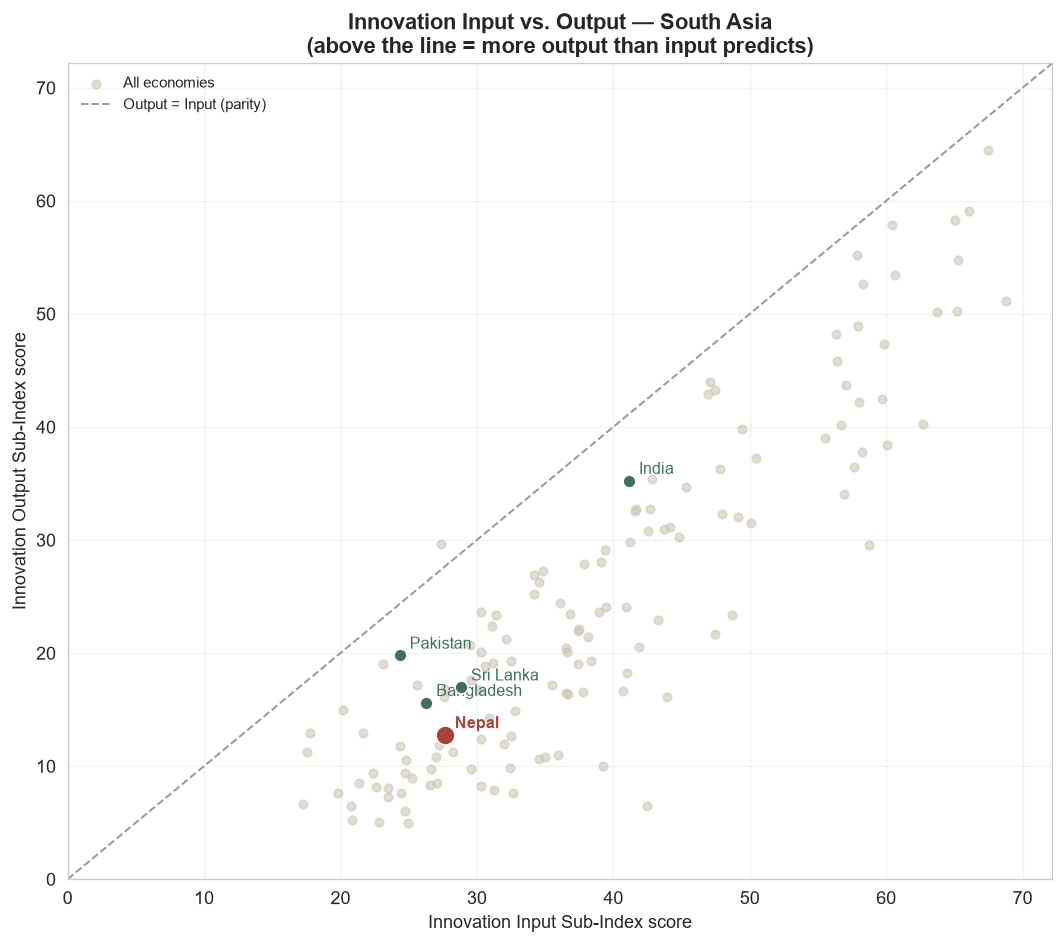

In [5]:
quad = data[data.NUM.isin(["IN", "OUT"])].pivot(
    index="ECONOMY_NAME", columns="NUM", values="SCORE"
).dropna()

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(quad["IN"], quad["OUT"], s=26, color="#c9c2b0", alpha=0.55, zorder=2, label="All economies")

lims = [0, max(quad["IN"].max(), quad["OUT"].max()) * 1.05]
ax.plot(lims, lims, color="#999999", linestyle="--", linewidth=1.2, zorder=1, label="Output = Input (parity)")

for name in SOUTH_ASIA:
    if name in quad.index:
        x, y = quad.loc[name, "IN"], quad.loc[name, "OUT"]
        color = "#A6423A" if name == NEPAL else "#3E6E64"
        size = 130 if name == NEPAL else 60
        ax.scatter(x, y, s=size, color=color, zorder=3, edgecolor="white", linewidth=1)
        ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, 4),
                    fontsize=9.5, fontweight="bold" if name == NEPAL else "normal", color=color)

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Innovation Input Sub-Index score")
ax.set_ylabel("Innovation Output Sub-Index score")
ax.set_title("Innovation Input vs. Output — South Asia\n(above the line = more output than input predicts)")
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "gii_fig1_input_output_quadrant.png", bbox_inches="tight")
plt.show()

## 4. Figure 2 — Pillar rank bump chart

Nepal's rank (not score) across all 7 pillars, connected as a line, with 
South Asia peers as faint background lines. Ranks make cross-pillar 
comparison intuitive (lower = better) in a way raw scores on different 
scales don't.

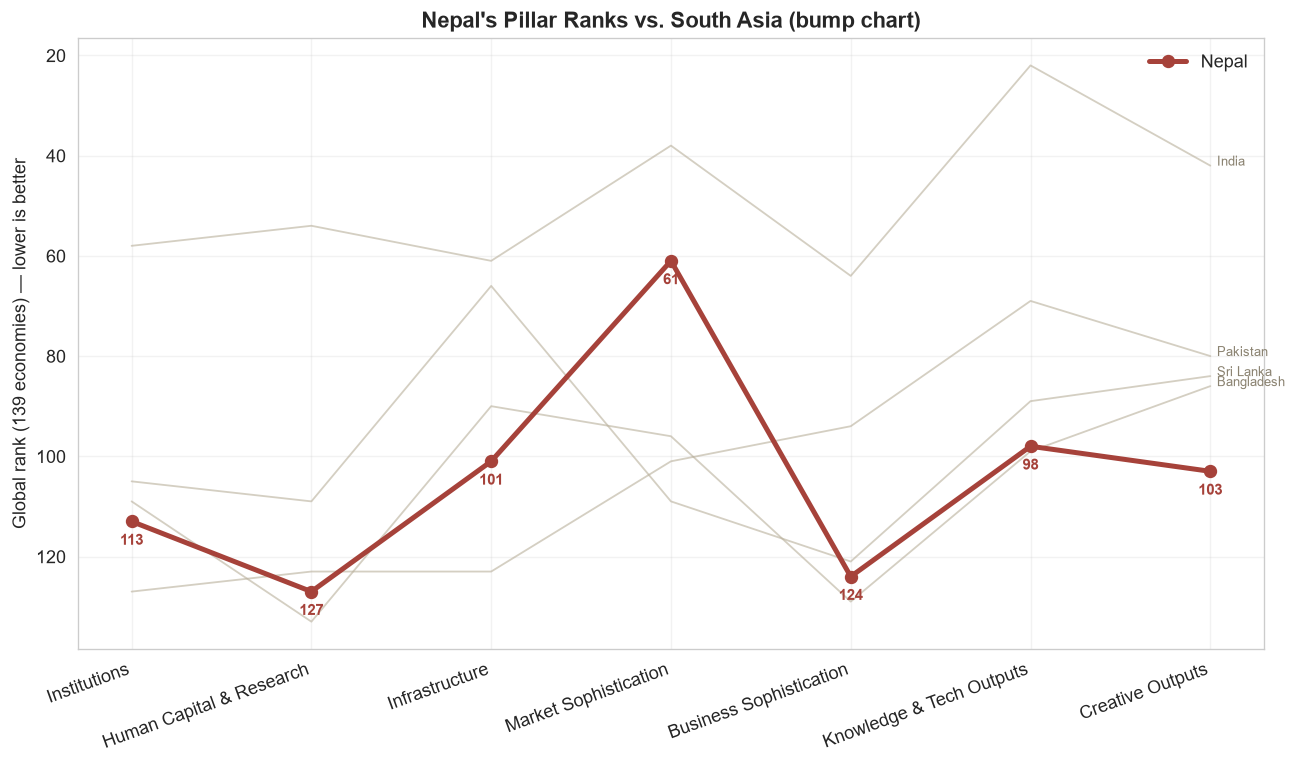

In [6]:
pillar_ranks = data[data.NUM.isin(PILLAR_CODES.keys())].pivot(
    index="ECONOMY_NAME", columns="NUM", values="RANK"
)[list(PILLAR_CODES.keys())]

fig, ax = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(PILLAR_CODES))

for name in pillar_ranks.index:
    if name in SOUTH_ASIA and name != NEPAL:
        ax.plot(x, pillar_ranks.loc[name], color="#B8AF9A", linewidth=1.1, alpha=0.6, zorder=1)
        ax.annotate(name, (x[-1], pillar_ranks.loc[name].iloc[-1]), fontsize=8, color="#8a8270",
                    xytext=(4, 0), textcoords="offset points")

ax.plot(x, pillar_ranks.loc[NEPAL], color="#A6423A", linewidth=3, marker="o", markersize=7, zorder=3, label="Nepal")
for xi, yi in zip(x, pillar_ranks.loc[NEPAL]):
    ax.annotate(f"{int(yi)}", (xi, yi), textcoords="offset points", xytext=(0, -14),
                ha="center", fontsize=9, color="#A6423A", fontweight="bold")

ax.invert_yaxis()  # rank 1 at top
ax.set_xticks(x)
ax.set_xticklabels(PILLAR_CODES.values(), rotation=20, ha="right")
ax.set_ylabel("Global rank (139 economies) — lower is better")
ax.set_title("Nepal's Pillar Ranks vs. South Asia (bump chart)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "gii_fig2_pillar_rank_bump.png", bbox_inches="tight")
plt.show()

## 5. Figure 3 — Single-indicator spotlight: microfinance loans

The one indicator where Nepal ranks at or near global 1st. Every economy as 
a dot on one axis; Nepal called out. Deliberately minimal — the point is the 
contrast with Figure 2, not a comprehensive view.

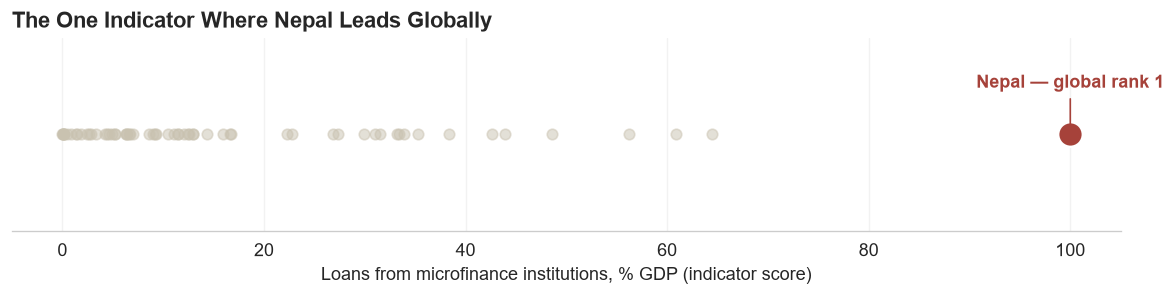

In [7]:
MICROFINANCE = "IN.4.1.3"  # Loans from microfinance institutions, % GDP

mf = data[data.NUM == MICROFINANCE][["ECONOMY_NAME", "SCORE", "RANK"]].dropna()
nepal_mf_rank = mf.loc[mf.ECONOMY_NAME == NEPAL, "RANK"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.scatter(mf["SCORE"], np.zeros(len(mf)), s=40, color="#c9c2b0", alpha=0.5, zorder=2)
nep_row = mf[mf.ECONOMY_NAME == NEPAL]
ax.scatter(nep_row["SCORE"], [0], s=220, color="#A6423A", zorder=3, edgecolor="white", linewidth=1.5)
ax.annotate(f"Nepal — global rank {int(nepal_mf_rank)}", (nep_row.SCORE.iloc[0], 0),
            xytext=(0, 28), textcoords="offset points", ha="center",
            fontsize=11, fontweight="bold", color="#A6423A",
            arrowprops=dict(arrowstyle="-", color="#A6423A", lw=1))

ax.set_yticks([])
ax.set_xlabel("Loans from microfinance institutions, % GDP (indicator score)")
ax.set_title("The One Indicator Where Nepal Leads Globally", loc="left")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "gii_fig3_microfinance_spotlight.png", bbox_inches="tight")
plt.show()

## 6. Figure 4 — Small multiples: patents vs. output score, South Asia

Two bars per country, not a grid — a deliberately minimal confirmatory 
check rather than a headline figure.

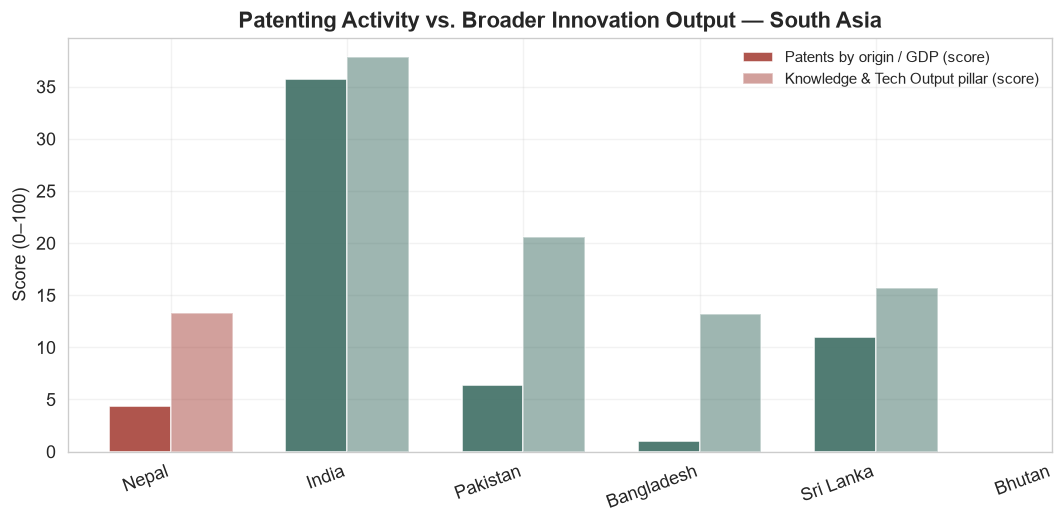

,Patents/GDP (score),Knowledge & Tech Output (pillar score)
Economy,,
Nepal,4.321079,13.248696
India,35.712404,37.812091
Pakistan,6.344300,20.579317
Bangladesh,0.999088,13.168158
Sri Lanka,10.968712,15.713215
Bhutan,NaN,NaN


In [8]:
PATENTS_BY_ORIGIN = "OUT.6.1.1"  # Patents by origin / bn PPP$ GDP

pairs = []
for name in SOUTH_ASIA:
    pairs.append({
        "Economy": name,
        "Patents/GDP (score)": get_score(name, PATENTS_BY_ORIGIN),
        "Knowledge & Tech Output (pillar score)": get_score(name, "OUT.6"),
    })
pairs_df = pd.DataFrame(pairs).set_index("Economy")
pairs_df.to_csv(PROCESSED_DIR / "gii_south_asia_patents_vs_output.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(pairs_df))
width = 0.35
colors = ["#A6423A" if e == NEPAL else "#3E6E64" for e in pairs_df.index]
ax.bar(x - width/2, pairs_df["Patents/GDP (score)"], width, label="Patents by origin / GDP (score)", color=colors, alpha=0.9)
ax.bar(x + width/2, pairs_df["Knowledge & Tech Output (pillar score)"], width,
       label="Knowledge & Tech Output pillar (score)", color=colors, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(pairs_df.index, rotation=20, ha="right")
ax.set_ylabel("Score (0–100)")
ax.set_title("Patenting Activity vs. Broader Innovation Output — South Asia")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "gii_fig4_patents_vs_output.png", bbox_inches="tight")
plt.show()
pairs_df

## 7. Nepal scorecard export

In [9]:
key_indicators = {
    "GII overall": None, "Innovation Inputs": "IN", "Innovation Outputs": "OUT",
    **PILLAR_CODES, "Microfinance loans, % GDP": MICROFINANCE, "Patents by origin/GDP": PATENTS_BY_ORIGIN,
}

rows = []
for label, code in key_indicators.items():
    if code is None:
        r = data[(data.ECONOMY_NAME == NEPAL) & (data.NAME == "Global Innovation Index")]
    else:
        r = data[(data.ECONOMY_NAME == NEPAL) & (data.NUM == code)]
    if len(r):
        rows.append({"Metric": label, "Score": round(r.SCORE.iloc[0], 2), "Rank (of 139)": int(r.RANK.iloc[0])})

nepal_gii_scorecard = pd.DataFrame(rows)
nepal_gii_scorecard.to_csv(PROCESSED_DIR / "nepal_gii_scorecard.csv", index=False)
with open(PROCESSED_DIR / "nepal_gii_scorecard.md", "w") as f:
    f.write(nepal_gii_scorecard.to_markdown(index=False))
nepal_gii_scorecard

,Metric,Score,Rank (of 139)
0,GII overall,20.21,107
1,Innovation Inputs,27.65,107
2,Innovation Outputs,12.76,101
3,"Microfinance loans, % GDP",100.00,1
4,Patents by origin/GDP,4.32,98
